# Load environment variables from .env file

In [12]:
## Get data from https://fundamentus.com.br/detalhes.php?papel=<papel> and then store values on a python datashhet

# Load environment variables for secure API key management
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Example: Access API keys securely
# gemini_api_key = os.getenv('GEMINI_API_KEY')
# alpha_vantage_api_key = os.getenv('ALPHA_VANTAGE_API_KEY')

# Verify environment variables are loaded (optional)
# if not gemini_api_key:
#     print("Warning: GEMINI_API_KEY not found in environment variables")
# else:
#     print("API keys loaded successfully")

True

## Get data from https://fundamentus.com.br/detalhes.php?papel=<papel> and then store values on a python datashhet

# Read Position

In [13]:
#conda activate base
import pandas as pd


# Current cash reserve
CurrentCashReserve = "20.0%"
# Lê o arquivo Excel
path = "/home/ponche/projects/ibox/b3/"
#fileName = "posicao-2025-12-06-15-13-40.xlsx"
import os
import glob
files = glob.glob(path + 'posicao-*.xlsx')
if not files:
    raise FileNotFoundError(f'Nenhum arquivo posicao-*.xlsx encontrado em {path}')
file = max(files)

print (file)
df_posicao = pd.read_excel(file, sheet_name='Acoes', header=0, skiprows=0, nrows=300)
#df_posicao = pd.read_excel(file, sheet_name='Posição - Ações', header=0, skiprows=0, nrows=300)

#print(df_posicao.columns)
#print(df_posicao['Código de Negociação'])
df_posicao = df_posicao.dropna(subset=['Código de Negociação'])

cash_reserve_float = float(CurrentCashReserve.strip('%')) / 100.0
df_posicao['Percentual'] = (df_posicao['Valor Atualizado'] / df_posicao['Valor Atualizado'].sum()) * (1 - cash_reserve_float)


/home/ponche/projects/ibox/b3/posicao-2026-04-27-09-31-43.xlsx


/home/ponche/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


# Function to get tiker price

In [14]:
import yfinance as yf

def get_quotation(ticker):
    """
    Recebe o ticker de uma ação e retorna o último preço de fechamento ou em tempo real.
    """
    try:
        acao = yf.Ticker(ticker)
        
        # 1. Tenta pegar o preço em tempo real (mais rápido que baixar o histórico)
        preco_atual = acao.fast_info.get('lastPrice')
        
        if preco_atual is None or preco_atual == 0:
            # 2. Fallback: Se fast_info falhar, tenta pegar do info
            preco_atual = acao.info.get('currentPrice', 0)
            
        if preco_atual is None or preco_atual == 0:
            # 3. Última tentativa: Baixa o histórico dos últimos 5 dias e pega a última linha (iloc[-1])
            dados = acao.history(period="5d")
            if not dados.empty:
                preco_atual = dados['Close'].iloc[-1]
            else:
                preco_atual = 0.0
                
        return float(preco_atual)
    
    except Exception as e:
        return 0.0

print(get_quotation("ABEV3" + ".SA"))


14.5


# Create a function to get tiker data

In [15]:
import pandas as pd
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import time
import math
import gc

def converter_float(texto):
    texto = texto.replace(",", ".")
    if texto.endswith("%"):
        texto = texto[:-1]  # remove o símbolo de porcentagem
        if texto != "0" and texto != 0:
            return float(texto) / 100
        else:
            return 0
    else:
        try:
            return float(texto)
        except ValueError:
            return 0

def get_ticker_data(ticker):
    tk = ticker['Código de Negociação']
    percentual = ticker['Percentual']
    
    # Create a new Chrome browser instance
    driver = webdriver.Chrome()
    driver.implicitly_wait(10)
    
    try:
        # Go to the fundamentus website
        driver.get(f"https://fundamentus.com.br/detalhes.php?papel={tk}")

        # Find the search bar element by its name attribute
        SETOR = driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[1]/tbody/tr[4]/td[2]/span/a").text
        COTACAO = get_quotation(tk + ".SA")
        
        PL = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[2]/td[4]/span").text)
        LPA = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[2]/td[6]/span").text)

        P_V = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[3]/td[4]/span").text)
        VPA = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[3]/td[6]/span").text)

        P_EBIT = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[4]/td[4]/span").text)
        MARGEM_BRUTA = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[4]/td[6]/span").text)

        PSR = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[5]/td[4]/span").text)
        MARGEM_EBITDA = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[5]/td[6]/span").text)

        P_ATIVOS = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[6]/td[4]/span").text)
        MARGEM_LIQUIDA = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[6]/td[6]/span").text)

        CAP_GIRO = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[7]/td[4]/span").text)
        EBIT_ATIVO = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[7]/td[6]/span").text)

        ATIVO_CIRCUL_LIQU = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[8]/td[4]/span").text)
        ROIC = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[8]/td[6]/span").text)

        DIV_YELD = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[9]/td[4]/span").text)
        ROE = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[9]/td[6]/span").text)

        EV_EBITIDA = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[10]/td[4]/span").text)
        LIQUIDES_CORR = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[10]/td[6]/span").text)

        EV_EBIT = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[11]/td[4]/span").text)
        DIV_PATRIMONIO = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[11]/td[6]/span").text)

        CRES_REC_5A = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[12]/td[4]/span").text)
        GIRO_ATIVOS = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[12]/td[6]/span").text)

        resultado = 22.5 * float(LPA) * float(VPA)
        if resultado >= 0:
            PRECO_JUSTO = math.sqrt(resultado)
        else:
            PRECO_JUSTO = 0  # ou algum outro valor que faça sentido para o seu caso

        lineData = {
            'TIKER': [tk], 'SETOR' : [SETOR], 'COTACAO': [COTACAO], 
            'PERCENTUAL' : [percentual], 'PRECO_JUSTO' : [PRECO_JUSTO],
            'PL': [PL], 'LPA': [LPA],
            'P_V': [P_V], 'VPA': [VPA],
            'P_EBIT': [P_EBIT], 'MARGEM_BRUTA': [MARGEM_BRUTA],
            'PSR': [PSR], 'MARGEM_EBITDA': [MARGEM_EBITDA],
            'P_ATIVOS': [P_ATIVOS], 'MARGEM_LIQUIDA': [MARGEM_LIQUIDA],
            'CAP_GIRO': [CAP_GIRO], 'EBIT_ATIVO': [EBIT_ATIVO],
            'ATIVO_CIRCUL_LIQU': [ATIVO_CIRCUL_LIQU], 'ROIC': [ROIC],
            'DIV_YELD': [DIV_YELD], 'ROE': [ROE],
            'EV_EBITIDA': [EV_EBITIDA], 'LIQUIDES_CORR': [LIQUIDES_CORR],
            'EV_EBIT': [EV_EBIT], 'DIV_PATRIMONIO': [DIV_PATRIMONIO],
            'CRES_REC_5A': [CRES_REC_5A], 'GIRO_ATIVOS': [GIRO_ATIVOS]
        }

        libeDF = pd.DataFrame(lineData)
        libeDF['DIFERENCA'] = libeDF['PRECO_JUSTO'] - libeDF['COTACAO'] 
        
        return libeDF
        
    except Exception as e:
        print(f"Erro ao extrair dados de {tk}: {e}")
        return pd.DataFrame()
        
    finally:
        # Close the browser window
        driver.quit()
        # Libera a memória do driver 
        del driver
        gc.collect()


# Loop function in all b3 tikers to create a DataFrame

In [16]:
import concurrent.futures

tickers = [
   "ABCB4", "BBSE3", "JHSF3", "CMIN3", "LIGT3", "AXIA6", "ALOS3", "VIVT3", "VLID3", "CGAS3",
   "EGIE3", "CXSE3", "PRIO3", "PSSA3", "EALT4", "GRND3", "WEGE3" , "SMTO3", "WEGE3", "JALL3", 
   "TTEN3", "BMGB4", "SAPR4", "LPSB3", "CAMB3", "RIAA3", "LUXM4", "ALLD3", "EQPA3", "CSED3",
   "CSUD3", "GMAT3", "RSUL4", "WISC3", "CEEB3"

]
tikers = list(dict.fromkeys(tickers))

df = pd.DataFrame()  # Initialize an empty dataframe

print (time.strftime("%Y-%m-%d %H:%M:%S", time.gmtime()))

# Prepara a lista de dicionários para os tickets estáticos
tasks = [{'Código de Negociação': tk, 'Percentual': 0} for tk in tickers]

# Prepara a lista de tarefas da posição atual
N = 0
for index, row in df_posicao.iterrows():
    N += 1
    tasks.append(row)
    if N > 1000:
        break

def process_ticker(tk_dict):
    print(f"Processando: {tk_dict['Código de Negociação']}")
    return get_ticker_data(tk_dict)

# Usa o ThreadPoolExecutor com max_workers=3 para ter 3 processos concorrentes
with concurrent.futures.ThreadPoolExecutor(max_workers=6) as executor:
    # Submete todas as tarefas
    future_to_tk = {executor.submit(process_ticker, task): task for task in tasks}
    
    for future in concurrent.futures.as_completed(future_to_tk):
        tk_dict = future_to_tk[future]
        try:
            libeDF = future.result()
            if libeDF is not None and not libeDF.empty:
                if df.empty:
                    df = libeDF
                else:
                    df = pd.concat([df, libeDF], ignore_index=True)
        except Exception as exc:
            tk = tk_dict['Código de Negociação']
            print(f"A extração de {tk} gerou uma exceção: {exc}")

print (time.strftime("%Y-%m-%d %H:%M:%S", time.gmtime()))
print(df)  # Print the resulting dataframe


2026-04-28 13:53:15
Processando: ABCB4
Processando: BBSE3
Processando: JHSF3
Processando: CMIN3
Processando: LIGT3
Processando: AXIA6
Processando: ALOS3
Processando: VIVT3
Processando: VLID3
Processando: CGAS3
Processando: EGIE3
Processando: CXSE3
Processando: PRIO3


$CGAS3.SA: possibly delisted; no price data found  (period=5d)


Processando: PSSA3
Processando: EALT4
Processando: GRND3
Processando: WEGE3
Processando: SMTO3
Processando: WEGE3
Processando: JALL3
Processando: TTEN3
Processando: BMGB4
Processando: SAPR4
Processando: LPSB3
Processando: CAMB3
Processando: RIAA3
Processando: LUXM4
Processando: ALLD3
Processando: EQPA3
Processando: CSED3
Processando: CSUD3
Processando: GMAT3
Processando: RSUL4
Processando: WISC3
Processando: CEEB3
Processando: ABCB4
Processando: AZZA3
Processando: BBAS3
Processando: BBAS3
Processando: BBSE3
Processando: BRAP3
Processando: BRSR6
Processando: EALT4
Processando: FESA4
Processando: GGBR4
Erro ao extrair dados de WISC3: Message: no such element: Unable to locate element: {"method":"xpath","selector":"/html/body/div[1]/div[2]/table[1]/tbody/tr[4]/td[2]/span/a"}
  (Session info: chrome=147.0.7727.101); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#nosuchelementexception
Stacktrace:
#0 0x55dae9f5779a <unk

# Group repeated tiker and sumarize percentage

In [17]:
# Agrupar os TIKERs repetidos e somar o percentual, mantendo todas as colunas
df_grouped = df.groupby('TIKER', as_index=False).agg({
    col: 'first' if col not in ['PERCENTUAL'] else 'sum' for col in df.columns
})

print(df_grouped)


    TIKER                            SETOR     COTACAO  PERCENTUAL  \
0   ABCB4       Intermediários Financeiros   24.870001    0.055277   
1   ALLD3                         Comércio    6.480000    0.000000   
2   ALOS3            Exploração de Imóveis   30.940001    0.000000   
3   AXIA6                 Energia Elétrica   67.830002    0.000000   
4   AZZA3                         Comércio   21.750000    0.050350   
5   BBAS3       Intermediários Financeiros   22.430000    0.108967   
6   BBSE3            Previdência e Seguros   33.990002    0.026971   
7   BMGB4       Intermediários Financeiros    5.370000    0.000000   
8   BRAP3                        Mineração   20.120001    0.019377   
9   BRSR6       Intermediários Financeiros   15.570000    0.055592   
10  CAMB3    Tecidos, Vestuário e Calçados    9.700000    0.000000   
11  CEEB3                 Energia Elétrica   50.000000    0.000000   
12  CGAS3                              Gás  129.980000    0.000000   
13  CMIN3           

# Send dataframe to csv file

In [18]:
#df.to_excel('C:/GitProjects/training/tikers.xlsx', index=False)
#df.to_csv('/home/ponche/projects/ibox/results/tikers.csv')
df_grouped.to_csv('/home/ponche/projects/ibox/results/tikers_grouped.csv')

# Chart alocation stock

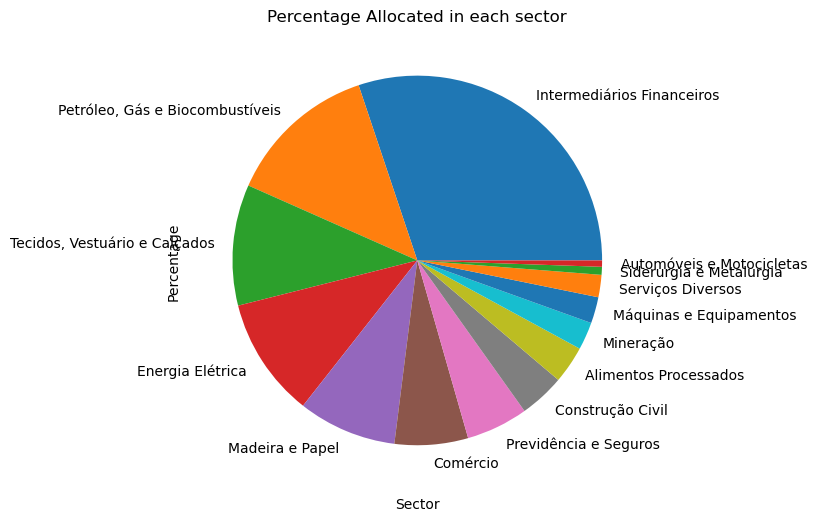

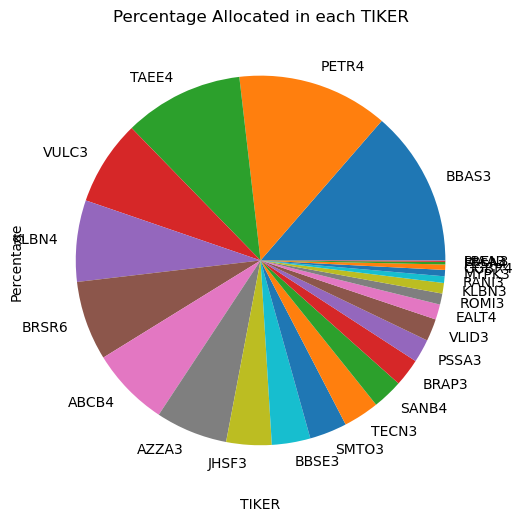

In [19]:
#create a chart using df dataframe to show the percentage alocated in each Tiker
import matplotlib.pyplot as plt
#print(df)

sector_data = df_grouped.groupby('SETOR')['PERCENTUAL'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sector_data.plot(kind='pie')
plt.title('Percentage Allocated in each sector')
plt.xlabel('Sector')
plt.ylabel('Percentage')
plt.show()

import matplotlib.pyplot as plt2

sector_data2 = df_grouped.groupby('TIKER')['PERCENTUAL'].sum().sort_values(ascending=False)

plt2.figure(figsize=(10, 6))
sector_data2.plot(kind='pie')
plt2.title('Percentage Allocated in each TIKER')
plt2.xlabel('TIKER')
plt2.ylabel('Percentage')
plt2.show()



# Call Kimi (Moonshot AI) via NVIDIA NIM
- Note: Uses requests library (standard Python) 
- API Endpoint: https://integrate.api.nvidia.com/v1/chat/completions
- Model: moonshotai/kimi-k2.5

Token generation: https://build.nvidia.com/moonshotai/kimi-k2.5

In [20]:
import requests
import base64
import os
from dotenv import load_dotenv

load_dotenv()

invoke_url = "https://integrate.api.nvidia.com/v1/chat/completions"
stream = False

# Check if API key is loaded
api_key = os.getenv('KIMI_API_KEY')
if not api_key:
    print("ERROR: KIMI_API_KEY not found in environment variables!")
    print("Make sure your .env file contains: KIMI_API_KEY=your_key_here")
else:
    print(f"API Key loaded: {api_key[:10]}... (length: {len(api_key)})")

headers = {
  "Authorization": f"Bearer {api_key}",
  "Accept": "text/event-stream" if stream else "application/json"
}

def call_kimi(prompt_content, max_tokens=8000, temperature=0.3, timeout_seconds=300):
    """Call Kimi via NVIDIA NIM API with configurable timeout"""
    payload = {
        "model": "moonshotai/kimi-k2-instruct-0905",
        "messages": [{"role": "user", "content": prompt_content}],
        "max_tokens": max_tokens,
        "temperature": temperature,
        "top_p": 1.00,
        "stream": stream,
    }
    
    print(f"  Sending request to {invoke_url}...")
    print(f"  Payload size: {len(str(prompt_content))} characters")
    print(f"  Max tokens: {max_tokens}")
    print(f"  Timeout: {timeout_seconds} seconds ({timeout_seconds//60} minutes)")
    
    try:
        response = requests.post(invoke_url, headers=headers, json=payload, timeout=timeout_seconds)
        print(f"  Response status: {response.status_code}")
        
        response.raise_for_status()
        
        if stream:
            result = ""
            for line in response.iter_lines():
                if line:
                    result += line.decode('utf-8') + "\n"
            return result
        else:
            result = response.json()
            
            # Check for API-level errors
            if 'error' in result:
                print(f"  API Error: {result['error']}")
                return None
            
            # Check choices
            if 'choices' not in result or len(result['choices']) == 0:
                print(f"  No choices in response: {result}")
                return None
            
            choice = result['choices'][0]
            
            # Check finish reason
            finish_reason = choice.get('finish_reason', 'unknown')
            print(f"  Finish reason: {finish_reason}")
            
            # Get message content
            message = choice.get('message', {})
            content = message.get('content')
            
            if content is None:
                print(f"  WARNING: Content is None! Message: {message}")
                reasoning = message.get('reasoning_content', '')
                if reasoning:
                    print(f"  Got reasoning_content instead: {len(reasoning)} chars")
                    return reasoning
                return None
            
            print(f"  Got content of length: {len(content)}")
            return content
                
    except requests.exceptions.Timeout as e:
        print(f"  TIMEOUT ERROR: Request took longer than {timeout_seconds} seconds")
        return None
    except requests.exceptions.RequestException as e:
        print(f"  Request Error: {str(e)}")
        return None
    except Exception as e:
        print(f"  Unexpected Error: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

def analyze_context_kimi():
    """Get macroeconomic context using Kimi"""
    prompt = """I want to know macroeconomic context to invest in companies listed in B3 bolsa Brasil.
- Take into consideration what most investment companies consider
- Keep it in maximum 5 lines
- Return in text format only"""
    
    print(f"Analyzing Context with Kimi...")
    return call_kimi(prompt, max_tokens=2000, temperature=0.3, timeout_seconds=60)

def analyze_portfolio_kimi(file_path):
    """Analyze portfolio using Kimi"""
    # Read only top holdings to reduce payload size
    try:
        import pandas as pd
        df = pd.read_csv(file_path)
        # Sort by percentual and take top 50
        df_top = df.nlargest(50, 'PERCENTUAL')
        csv_content = df_top.to_csv(index=False)
        print(f"  CSV file read: {len(csv_content)} characters (top 50 holdings)")
    except Exception as e:
        print(f"  ERROR reading CSV: {e}")
        return f"Error reading CSV: {e}"
    
    CurrentCashReserve = "20.0%"
    
    prompt = f"""Create a concise HTML investment report for my portfolio.

Analyze these top holdings and provide recommendations:
- High-Risk stocks to consider selling
- Dividend stocks to keep/buy  
- Growth stocks with potential

For each category, list: Ticker, Sector, % Allocation, Current Price, P/L ratio, Key recommendation, brief justification.

Requirements:
- Clean HTML with basic CSS styling
- One table per category
- Prioritize highest allocation stocks
- Link tickers to: https://br.tradingview.com/symbols/BMFBOVESPA-TICKER
- Current cash reserve: {CurrentCashReserve}
- NO markdown code blocks, just raw HTML

CSV data (top 50 holdings):
{csv_content}"""
    
    print(f"Analyzing {file_path} with Kimi...")
    # Reduced max_tokens and simpler prompt for faster generation
    return call_kimi(prompt, max_tokens=16000, temperature=0.6, timeout_seconds=60*6)

# Execute the analysis
print("="*60)
print("STEP 1: Testing Context Analysis")
print("="*60)
context_kimi = analyze_context_kimi()
print(f"\nContext result: {context_kimi if context_kimi else 'FAILED - got None'}")

print("\n" + "="*60)
print("STEP 2: Testing Portfolio Analysis")
print("="*60)
csv_file = "/home/ponche/projects/ibox/results/tikers_grouped.csv" 
html_report_kimi = analyze_portfolio_kimi(csv_file)

# Handle the result
if html_report_kimi is None:
    print("\nERROR: Kimi API returned None for portfolio analysis")
    print("Setting fallback HTML...")
    html_report_kimi = "<html><body><h1>Error: Failed to get response from Kimi API</h1><p>Check API key and network connection.</p></body></html>"
elif isinstance(html_report_kimi, str) and html_report_kimi.startswith("Error:"):
    print(f"\nERROR from Kimi: {html_report_kimi}")
    html_report_kimi = f"<html><body><h1>{html_report_kimi}</h1></body></html>"
else:
    print(f"\nSUCCESS! Got response of length: {len(html_report_kimi)}")
    print(f"First 100 chars: {html_report_kimi[:100]}...")

print("\n" + "="*60)
print("Cell execution complete")
print("="*60)

API Key loaded: nvapi-K0HE... (length: 70)
STEP 1: Testing Context Analysis
Analyzing Context with Kimi...
  Sending request to https://integrate.api.nvidia.com/v1/chat/completions...
  Payload size: 210 characters
  Max tokens: 2000
  Timeout: 60 seconds (1 minutes)
  Response status: 200
  Finish reason: stop
  Got content of length: 372

Context result: Selic rate, real/dollar, and inflation expectations drive B3 flows; watch COPOM signals.  
GDP growth, fiscal trajectory, and political noise set risk premium for Brazilian equities.  
Commodity prices (iron ore, soy, oil) swing terms of trade and earnings of heavy B3 weights.  
Global liquidity (Fed, China) and ESG flows affect foreign allocation to B3 more than local.

STEP 2: Testing Portfolio Analysis
  CSV file read: 11123 characters (top 50 holdings)
Analyzing /home/ponche/projects/ibox/results/tikers_grouped.csv with Kimi...
  Sending request to https://integrate.api.nvidia.com/v1/chat/completions...
  Payload size: 11750 char

# Display kimi report here as well

In [21]:
import re

# Check if html_report_kimi exists and is valid
if 'html_report_kimi' not in globals() or html_report_kimi is None:
    print("ERROR: html_report_kimi is not defined or is None. Run the previous cell first.")
    html_report_kimi = "<html><body><h1>Error: No report data available</h1></body></html>"
elif html_report_kimi.startswith("Error:"):
    print(f"ERROR in report: {html_report_kimi}")
    html_report_kimi = f"<html><body><h1>{html_report_kimi}</h1></body></html>"

# Clean up markdown code blocks more robustly (if they exist)
if html_report_kimi and isinstance(html_report_kimi, str):
    html_report_kimi = re.sub(r'^```html\s*', '', html_report_kimi, flags=re.IGNORECASE)
    html_report_kimi = re.sub(r'^```\s*', '', html_report_kimi)
    html_report_kimi = re.sub(r'\s*```$', '', html_report_kimi)
    html_report_kimi = html_report_kimi.strip()

# Save to file
output_file = '/home/ponche/projects/ibox/reports/report_kimi.html'
with open(output_file, "w", encoding='utf-8') as f:
    f.write(html_report_kimi)

print(f"Report saved to {output_file}")

# For compatibility with display cell
html_report = html_report_kimi

from IPython.display import display, HTML
display(HTML(html_report_kimi))

Report saved to /home/ponche/projects/ibox/reports/report_kimi.html


# Send report thru email

In [22]:
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
import os

# --- CONFIGURAÇÕES ---
remetente = "marcos.ponche@gmail.com"  # Coloque o MESMO Gmail onde gerou a senha
senha_de_app = os.getenv('app_key') 
destinatario = "marcos.ponche@gmail.com"

# Criando a estrutura do E-mail
msg = MIMEMultipart('alternative')
msg['Subject'] = "📈 Relatório de Análise de Portfólio (Kimi)"
msg['From'] = remetente
msg['To'] = destinatario

# A variável html_report do seu notebook entra aqui como o corpo visual do e-mail
parte_html = MIMEText(html_report, 'html')
msg.attach(parte_html)

# Conectando ao servidor e enviando
try:
    print("Conectando ao servidor do Gmail...")
    server = smtplib.SMTP('smtp.gmail.com', 587)
    server.starttls() # Inicia a criptografia
    server.login(remetente, senha_de_app)
    
    print("Enviando o relatório...")
    server.sendmail(remetente, destinatario, msg.as_string())
    server.quit()
    print("✅ E-mail enviado com sucesso para", destinatario)
except Exception as e:
    print(f"❌ Erro ao enviar e-mail: {e}")

Conectando ao servidor do Gmail...
Enviando o relatório...
✅ E-mail enviado com sucesso para marcos.ponche@gmail.com
